In [2]:
import scanpy as sc
import pandas as pd

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [ ]:
adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/Integrated_MPN_scvi_genotyped_nb.h5ad')
adata = adata[adata.obs['cell_type'] != 'Monocyte/Platelet doublet (non-HSPC)'].copy() ### remove these as doublets
adata.obs['cell_type'] = adata.obs['cell_type'].cat.remove_unused_categories()

### simplify cell type names
adata.obs['cell_type'] = adata.obs['cell_type'].str.replace(' (non-HSPC)','', regex=False).str.replace(' (myeloid-primed)','', regex=False).str.replace(' 2','', regex=False).str.replace(' [tentative]','', regex=False)


In [4]:
HSPC_types = ['HSC','MPP','GMP','MEP','Early Erythroid','Early MK','Basophil/mast progenitor','CLP']
mature_types = ['T cell','B cell','MK','Erythroid','Classical monocyte','Non-classical monocyte','Activated monocyte','Neutrophil','pDC','pre-cDC']


In [6]:
marker_genes = pd.read_csv('../data/cell_typing_markers.csv')
all_genes = []
cols = marker_genes.columns[marker_genes.columns.str.contains('Marker')]
for cell_type in HSPC_types:
    genes = marker_genes.loc[marker_genes['cell_type_key'] == cell_type, cols].values.flatten()
    genes = genes[~pd.isna(genes)]
    all_genes.extend(genes.tolist())

/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


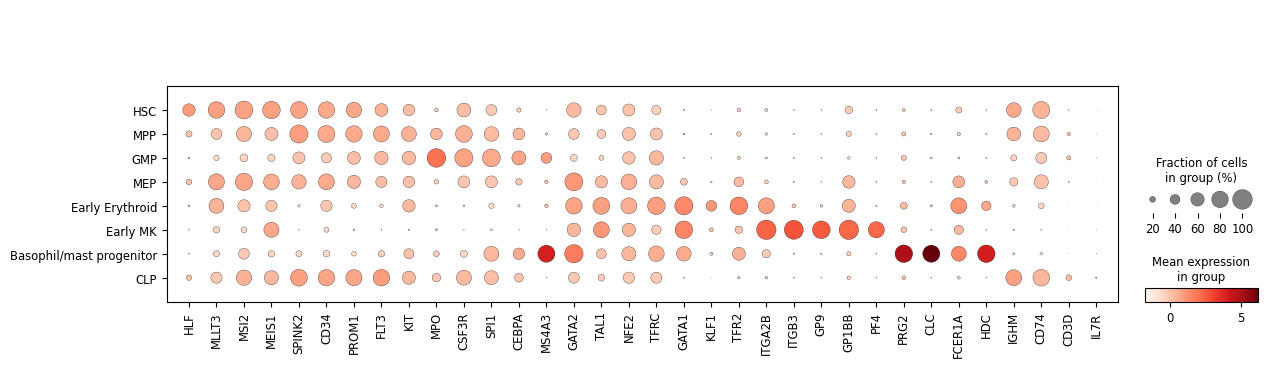

In [7]:
sc.pl.dotplot(
    adata[adata.obs['cell_type'].isin(HSPC_types)],
    var_names=list(dict.fromkeys(all_genes)),
    groupby='cell_type',
    layer='zs_norm_log',
    categories_order=HSPC_types, show=False
)

plt.savefig('../plots/MPN_HSPC_marker_dotplot.pdf', bbox_inches='tight')

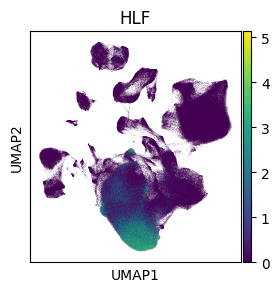

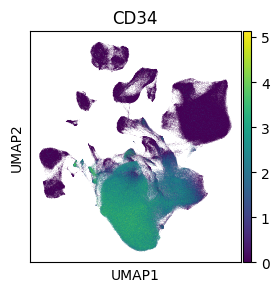

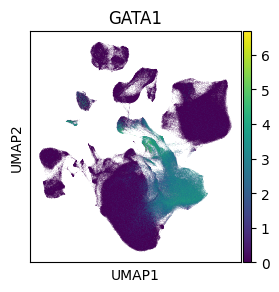

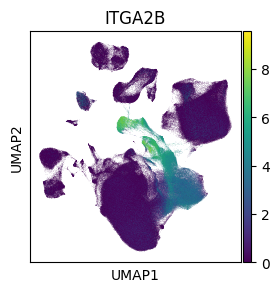

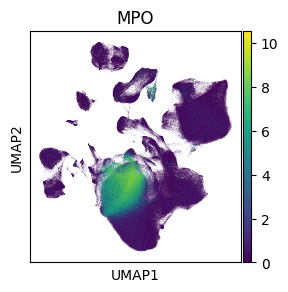

In [8]:
HSPC_markers = ['HLF','CD34','GATA1','ITGA2B','MPO']

for marker in HSPC_markers:
    fig,ax = plt.subplots(figsize=(3,3))
    sc.pl.umap(adata, color=marker, show=False, ax=ax)
    # Get current axes and rasterize scatter points
    ax = plt.gca()
    for coll in ax.collections:
        coll.set_rasterized(True)
    plt.savefig(f'../plots/MPN_HSPC_marker_{marker}_umap.pdf', bbox_inches='tight')


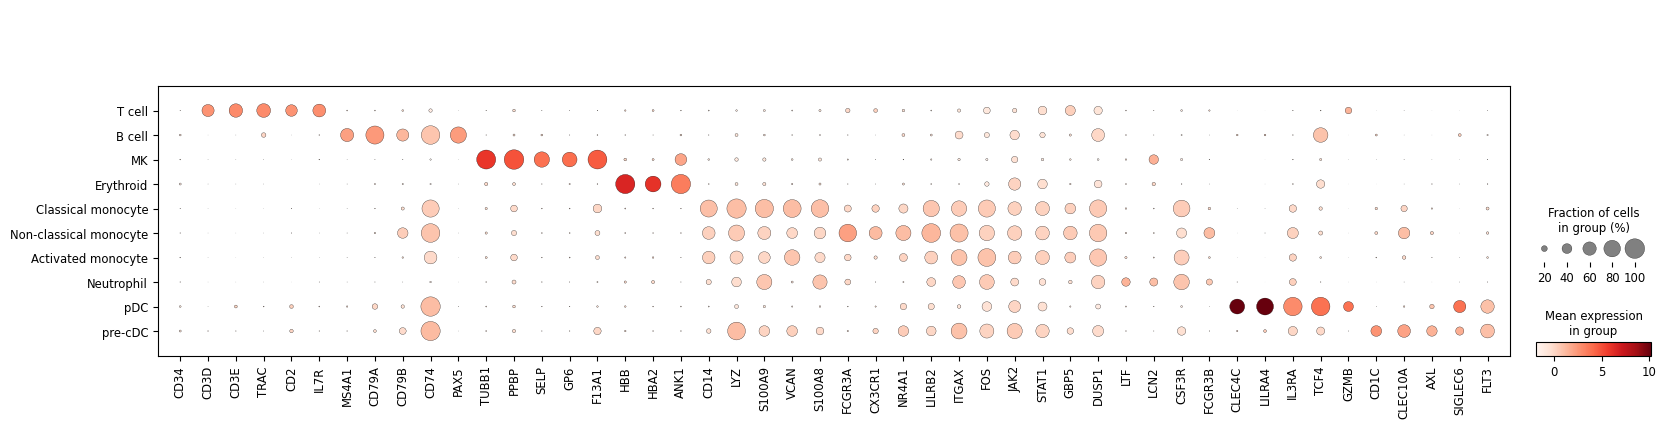

In [9]:
### then get markers for mature cell types
all_genes = ['CD34'] ### include for reference
cols = marker_genes.columns[marker_genes.columns.str.contains('Marker')]
for cell_type in mature_types:
    genes = marker_genes.loc[marker_genes['cell_type_key'] == cell_type, cols].values.flatten()
    genes = genes[~pd.isna(genes)]
    all_genes.extend(genes.tolist())


sc.pl.dotplot(
    adata[adata.obs['cell_type'].isin(mature_types)],
    var_names=list(dict.fromkeys(all_genes)),
    groupby='cell_type',
    layer='zs_norm_log',
    categories_order=mature_types, show=False
)
plt.savefig('../plots/MPN_mature_marker_dotplot.pdf', bbox_inches='tight')